In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kwentar/blur-dataset")

print("Path to dataset files:", path)

/opt/miniconda3/envs/ai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/sauravkarki/.cache/kagglehub/datasets/kwentar/blur-dataset/versions/2


In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
import torch
import torch.nn as nn
from torchvision.transforms import v2
import cv2

In [4]:
path = '/Users/sauravkarki/.cache/kagglehub/datasets/kwentar/blur-dataset/versions/2'
img=cv2.imread(path+'/defocused_blurred/0_IPHONE-SE_F.JPG')

In [5]:
transforms = v2.Compose([
    v2.ToImage(), v2.Resize((512,512)),
    v2.ToDtype(torch.float32, scale=True)
])

In [6]:
from torch.utils.data import Dataset, DataLoader

In [7]:
img_names = {}
blur=[]
sharp=[]

for img in os.listdir(path+'/defocused_blurred'):
    blur.append(img)

for img in os.listdir(path+'/sharp'):
    sharp.append(img)

blur.sort()
sharp.sort()

img_names['blur'] = blur
img_names['sharp'] = sharp

In [8]:
for key, value in img_names.items():
    print(f"Key: {key}, Length: {len(value)}")


Key: blur, Length: 350
Key: sharp, Length: 350


In [9]:
df = pd.DataFrame(img_names)

In [10]:
df.shape
df.head()

,blur,sharp
0,0_IPHONE-SE_F.JPG,0_IPHONE-SE_S.JPG
1,100_NIKON-D3400-35MM_F.JPG,100_NIKON-D3400-35MM_S.JPG
2,101_NIKON-D3400-35MM_F.JPG,101_NIKON-D3400-35MM_S.JPG
3,102_NIKON-D3400-35MM_F.JPG,102_NIKON-D3400-35MM_S.JPG
4,103_HUAWEI-P20_F.jpg,103_HUAWEI-P20_S.jpg


In [11]:
class MyData(Dataset):
    def __init__(self, df, blur_path, sharpen_path, transform):
        self.df = df
        self.blur_path = blur_path
        self.sharpen_path = sharpen_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        blur_image_path = os.path.join(self.blur_path, self.df['blur'][index])
        sharpen_image_path = os.path.join(self.sharpen_path, self.df['sharp'][index])

        bimg = cv2.imread(blur_image_path)
        simg = cv2.imread(sharpen_image_path)

        if bimg is None or simg is None:
            raise FileNotFoundError(f"Error loading images: {blur_image_path} or {sharpen_image_path}")

        x = self.transform(bimg)
        y = self.transform(simg)
        return x, y

In [12]:
train_df=df[:245]
test_df=df[245:300]
valid_df=df[300:]

In [13]:
blur_path = path + '/defocused_blurred'
sharp_path = path + '/sharp'

train_data = MyData(train_df,blur_path,sharp_path,transforms)
test_data = MyData(test_df,blur_path,sharp_path,transforms)
valid_data = MyData(valid_df,blur_path,sharp_path,transforms)

In [14]:
train_loader = DataLoader(train_data,batch_size=10,shuffle=True)
valid_loader = DataLoader(valid_data,batch_size=10,shuffle=True)
test_loader = DataLoader(test_data,batch_size=10,shuffle=True)

In [15]:
print(len(train_data))
print(len(valid_data))
print(len(test_data))

245
50
55


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
class UNET(nn.Module):
    def __init__(self):
        super(UNET, self).__init__()
        self.conv_block1 = self.conv_block(3, 64)   
        self.conv_block2 = self.conv_block(64, 128)
        self.conv_block3 = self.conv_block(128, 256)
        self.conv_block4 = self.conv_block(256, 512)
        self.conv_block5 = self.conv_block(512,1024)
        
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(1024 * 8 * 8, 4096)
        self.relu1 = nn.ReLU(inplace=True)
        self.dense2 = nn.Linear(4096, 1024 * 8 * 8)
        self.relu2 = nn.ReLU(inplace=True)
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(1024, 8, 8))

        self.up_conv1 = self.up_conv(1024, 512)
        self.up_conv2 = self.up_conv(512, 256)
        self.up_conv3 = self.up_conv(256, 128)
        self.up_conv4 = self.up_conv(128, 64)

        self.final_conv = nn.Conv2d(64, 3, kernel_size=3,padding='same').to(device)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding='same',bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding='same',bias=False),
            nn.ReLU(inplace=True)
        ).to(device)

    def up_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2,bias=False)
            # nn.ReLU(inplace=True)
        ).to(device)
    def pool(self, x):
        return nn.AvgPool2d(kernel_size=2, stride=2)(x).to(device)
    
    def forward(self, x):   

        out1 = self.conv_block1(x)
        pool1 = self.pool(out1)   #64, 64, 64
        
        out2 = self.conv_block2(pool1)
        pool2 = self.pool(out2)  #128, 32,32
        
        
        out3 = self.conv_block3(pool2)
        pool3 = self.pool(out3)
        
        out4 = self.conv_block4(pool3)
        pool4 = self.pool(out4)  #512, 16,16

        out5 = self.conv_block5(pool4)  #1024,8,8
        
        
        up1 = self.up_conv1(out5)  #512,16,16
        up1 = self.crop_and_concat(out4, up1) #1024,16,16
        up1 = self.conv_block(1024, 512)(up1) #512,16,16

        up2 = self.up_conv2(out4)
        up2 = self.crop_and_concat(out3, up2)
        up2 = self.conv_block(512, 256)(up2)  #256,32,32

        up3 = self.up_conv3(up2)
        up3 = self.crop_and_concat(out2, up3)
        up3 = self.conv_block(256, 128)(up3)

        up4 = self.up_conv4(up3)
        up4 = self.crop_and_concat(out1, up4)
        up4 = self.conv_block(128, 64)(up4)  # 64,128,128

        return self.final_conv(up4)  #3,128,128
    
    def crop_and_concat(self, first, second):
#         _, _, H, W = upsampled.size()
#         bypass = self.center_crop(bypass, H, W)
        return torch.cat((first, second), dim=1)

In [18]:
q = iter(train_loader)

In [19]:
x,y=next(q)

In [20]:
print(f"xshape: {x.shape}")
print(f"yshape: {y.shape}")

xshape: torch.Size([10, 3, 512, 512])
yshape: torch.Size([10, 3, 512, 512])


In [21]:
model=UNET()
l = nn.L1Loss(reduction = 'sum')
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002) 
total_step = len(train_loader)

In [22]:
model = model.to(device)

In [23]:
from tqdm import tqdm

num_epochs = 20

for epoch in range(num_epochs):
    epoch_loss = 0
    
    with tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch") as pbar:
        for i, (b_img, s_img) in enumerate(train_loader):  
            optimizer.zero_grad()
            b_img, s_img = b_img.to(device, dtype=torch.float), s_img.to(device, dtype=torch.float)
            
            outputs = model(b_img)
            loss = l(outputs, s_img)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix({'Loss': f'{loss.item():.4f}'})
            pbar.update(1)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {epoch_loss / len(train_loader):.4f}')

Epoch 1/20: 100%|██████████| 25/25 [16:56<00:00, 40.64s/batch, Loss=1841646.2500]


Epoch [1/20], Average Loss: 3535561.7000


Epoch 2/20: 100%|██████████| 25/25 [13:58<00:00, 33.53s/batch, Loss=1874217.2500]


Epoch [2/20], Average Loss: 3240586.8100


Epoch 3/20: 100%|██████████| 25/25 [13:21<00:00, 32.05s/batch, Loss=930758.0000] 


...

Epoch [18/20], Average Loss: 1284675.7725


Epoch 19/20: 100%|██████████| 25/25 [12:59<00:00, 31.17s/batch, Loss=640499.6875] 


Epoch [19/20], Average Loss: 1262690.4925


Epoch 20/20: 100%|██████████| 25/25 [13:07<00:00, 31.48s/batch, Loss=535322.4375] 

Epoch [20/20], Average Loss: 1305963.1775


In [24]:
w = iter(train_loader)
x, y = next(w)
x = x.to(device)
p = model(x)

In [37]:
import matplotlib.pyplot as plt
import numpy as np

In [38]:
def predict(t,i):
    image_tensor =t  
    image_tensor = image_tensor.squeeze(0)
    image_tensor = image_tensor.detach().cpu()
    image_tensor=image_tensor[i:i+1].view(3,512,512)
    image_np = image_tensor.numpy()
    image_np = np.transpose(image_np, (1, 2, 0))
    return image_np

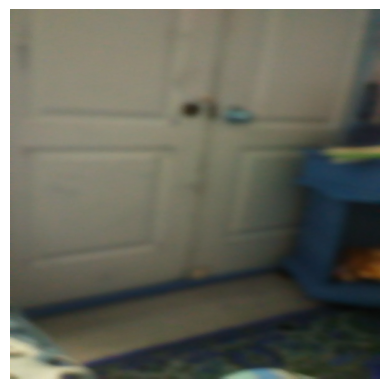

In [39]:
plt.imshow(predict(x,0))
plt.axis('off')
plt.show()

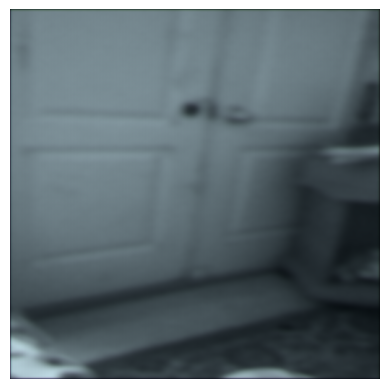

In [40]:
plt.imshow(predict(p,0))
plt.axis('off')
plt.show()

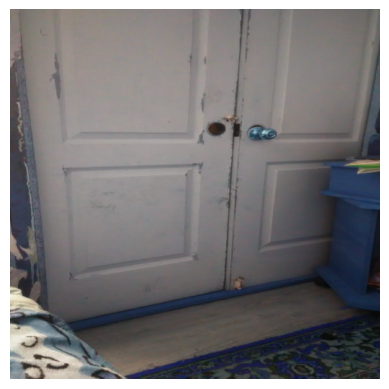

In [41]:
plt.imshow(predict(y,0))
plt.axis('off')
plt.show()

In [42]:
# Save the model state dictionary
# Save the model in the current directory
torch.save(model.state_dict(), "./model_state.pth")
print("Model saved successfully in the current directory.")

Model saved successfully in the current directory.
